# Project Introduction and Required Libraries

This notebook implements the **Smart Ride Fare, Estimated Time and Delay Risk Prediction System** using Machine Learning.

The system performs three tasks:

- **Fare Prediction** using regression
- **Estimated Travel Time Prediction** using regression
- **Delay Risk Prediction** using classification

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Load the Kaggle Dataset

In [4]:
df = pd.read_csv("./Dataset/fairfare_ride_demand_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 29)


# Display the First Records

In [68]:
df.head()

,City,Date,Day_of_Week,Latitude,Longitude,Ride_Distance_KM,Ride_Type,Weather,Event,Payment_Type,...,Fare_Acceptance,Cancellation_Rate,Time_of_Day,Demand_Score,Driver_Availability,Traffic_Delay,Cancellation_Probability,Driver_Trust_Score,Rider_Trust_Score,Leaderboard_Rank
0,Hyderabad,06-08-2024,1,17.353253,78.466332,6.76,Economy,Cloudy,Festival,UPI,...,0.857885,0.07,Afternoon,80,46,15,0.2,100.0,100,Below Average
1,Mumbai,26-09-2024,3,19.059839,72.858877,3.34,Premium,Stormy,Political Rally,Card,...,0.747193,0.07,Morning Peak,100,86,25,0.3,100.0,50,Below Average
2,Bangalore,27-07-2024,5,12.976855,77.625306,8.86,Luxury,Rainy,Festival,UPI,...,0.868523,0.08,Afternoon,100,32,15,0.3,100.0,100,Below Average
3,Mumbai,23-03-2025,6,19.056439,72.863508,15.95,Luxury,Cloudy,Concert,Cash,...,0.859991,0.07,Evening Peak,95,95,25,0.1,100.0,100,Below Average
4,Chennai,06-08-2024,1,13.110869,80.309381,19.50,Premium,Clear,NaN,Card,...,0.981357,0.05,Evening Peak,65,58,10,0.1,0.0,0,Below Average


# Check Dataset Dimensions and Column Names

In [129]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("Column Names:")
for column in df.columns:
    print(column)

Number of Rows: 10000
Number of Columns: 29
Column Names:
City
Date
Day_of_Week
Latitude
Longitude
Ride_Distance_KM
Ride_Type
Weather
Event
Payment_Type
Available_Drivers
Demand_Level
Surge_Multiplier
Final_Fare
Hour_of_Day
Is_Weekend
Driver_Performance_Score
Driver_XP
Ride_Priority
Fare_Acceptance
Cancellation_Rate
Time_of_Day
Demand_Score
Driver_Availability
Traffic_Delay
Cancellation_Probability
Driver_Trust_Score
Rider_Trust_Score
Leaderboard_Rank


# Inspect Dataset Information

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   City                      10000 non-null  object 
 1   Date                      10000 non-null  object 
 2   Day_of_Week               10000 non-null  int64  
 3   Latitude                  10000 non-null  float64
 4   Longitude                 10000 non-null  float64
 5   Ride_Distance_KM          10000 non-null  float64
 6   Ride_Type                 10000 non-null  object 
 7   Weather                   10000 non-null  object 
 8   Event                     7980 non-null   object 
 9   Payment_Type              10000 non-null  object 
 10  Available_Drivers         10000 non-null  float64
 11  Demand_Level              10000 non-null  float64
 12  Surge_Multiplier          10000 non-null  float64
 13  Final_Fare                10000 non-null  float64
 14  Hour_of

# Check Duplicate Records

In [132]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


# Remove Duplicate Records

In [133]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10000, 29)


# Identify Numerical and Categorical Columns

In [134]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Day_of_Week', 'Latitude', 'Longitude', 'Ride_Distance_KM', 'Available_Drivers', 'Demand_Level', 'Surge_Multiplier', 'Final_Fare', 'Hour_of_Day', 'Is_Weekend', 'Driver_Performance_Score', 'Driver_XP', 'Ride_Priority', 'Fare_Acceptance', 'Cancellation_Rate', 'Demand_Score', 'Driver_Availability', 'Traffic_Delay', 'Cancellation_Probability', 'Driver_Trust_Score', 'Rider_Trust_Score']

Categorical Columns:
['City', 'Date', 'Ride_Type', 'Weather', 'Event', 'Payment_Type', 'Time_of_Day', 'Leaderboard_Rank']


# Analyze City Distribution

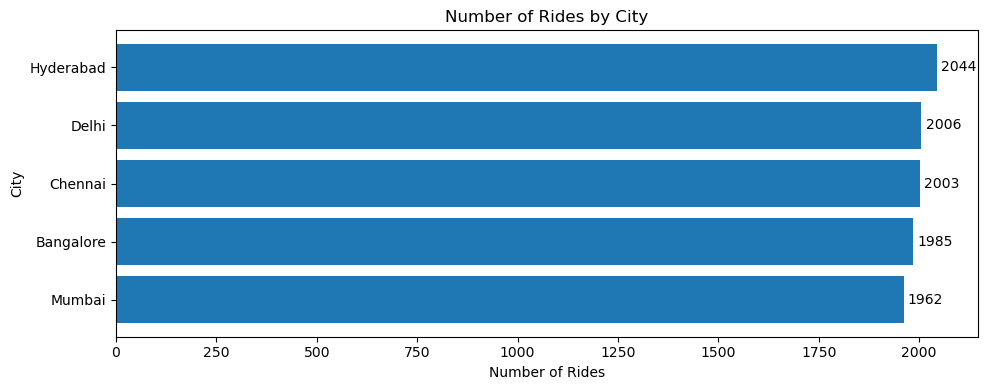

In [135]:
city_counts = df["City"].value_counts().sort_values()

plt.figure(figsize=(10, 4))

bars = plt.barh(city_counts.index, city_counts.values)

plt.xlabel("Number of Rides")
plt.ylabel("City")
plt.title("Number of Rides by City")

for bar in bars:
    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va="center"
    )

plt.tight_layout()
plt.show()

# Analyze Ride Type Distribution

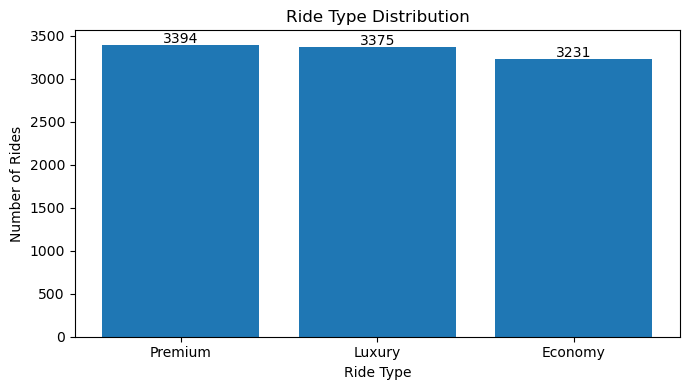

In [136]:
ride_counts = df["Ride_Type"].value_counts()

plt.figure(figsize=(7, 4))

bars = plt.bar(ride_counts.index, ride_counts.values)
plt.xlabel("Ride Type")
plt.ylabel("Number of Rides")
plt.title("Ride Type Distribution")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(int(bar.get_height())),
        ha="center"
    )

plt.tight_layout()
plt.show()

# Analyze Weather Distribution

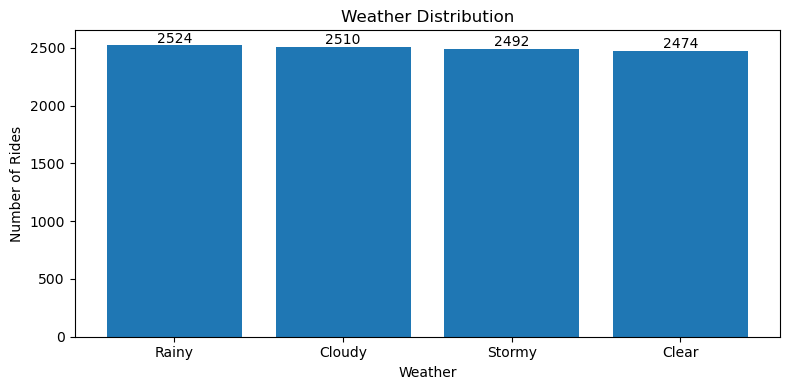

In [144]:
weather_counts = df["Weather"].value_counts()

plt.figure(figsize=(8, 4))

bars = plt.bar(weather_counts.index, weather_counts.values)
plt.xlabel("Weather")
plt.ylabel("Number of Rides")
plt.title("Weather Distribution")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(int(bar.get_height())),
        ha="center"
    )

plt.tight_layout()
plt.show()

# Analyze Final Fare Distribution

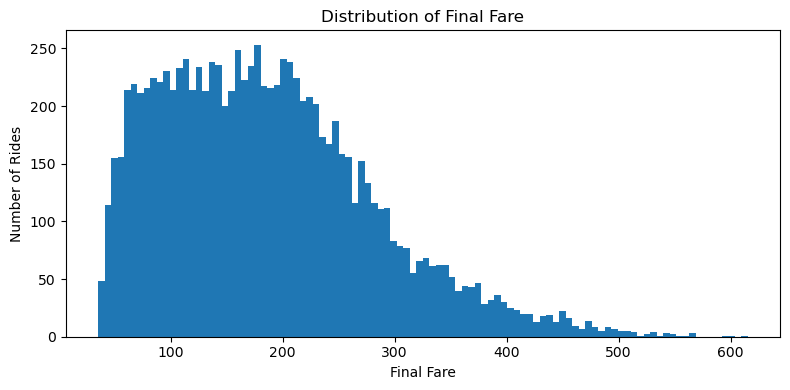

In [145]:
plt.figure(figsize=(8, 4))

plt.hist(df["Final_Fare"], bins=100)
plt.xlabel("Final Fare")
plt.ylabel("Number of Rides")
plt.title("Distribution of Final Fare")
plt.tight_layout()
plt.show()

# Analyze Distance and Fare Relationship

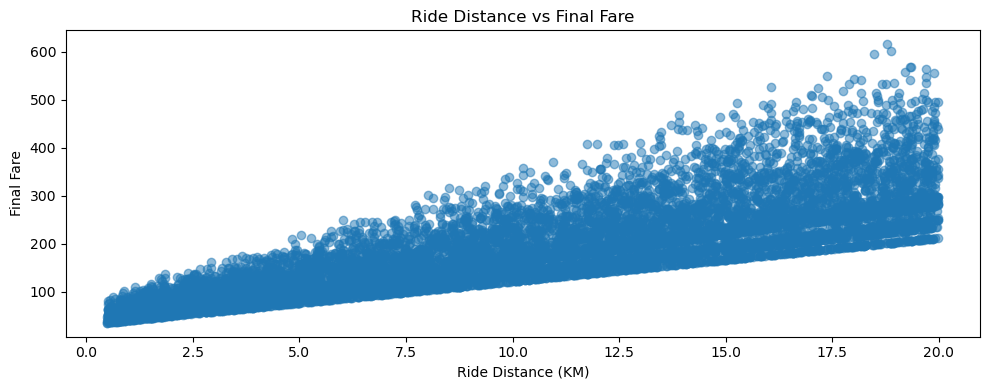

In [152]:
plt.figure(figsize=(10, 4))
plt.scatter(df["Ride_Distance_KM"], df["Final_Fare"], alpha=0.5)
plt.xlabel("Ride Distance (KM)")
plt.ylabel("Final Fare")
plt.title("Ride Distance vs Final Fare")
plt.tight_layout()
plt.show()

In [153]:
df_ml = df.copy()

print("Machine learning dataset shape:", df_ml.shape)

categorical_columns = [
    "City",
    "Day_of_Week",
    "Ride_Type",
    "Weather",
    "Event",
    "Payment_Type",
    "Demand_Level",
    "Ride_Priority",
    "Leaderboard_Rank"
]

print("\nCategorical columns selected for encoding:")
print(categorical_columns)

Machine learning dataset shape: (10000, 29)

Categorical columns selected for encoding:
['City', 'Day_of_Week', 'Ride_Type', 'Weather', 'Event', 'Payment_Type', 'Demand_Level', 'Ride_Priority', 'Leaderboard_Rank']


# Encode and Inspect Categorical Variables

In [156]:
encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df_ml[column] = encoder.fit_transform(df_ml[column].astype(str))
    encoders[column] = encoder

print("Categorical encoding completed.")
df_ml.head()


Categorical encoding completed.


,City,Date,Day_of_Week,Latitude,Longitude,Ride_Distance_KM,Ride_Type,Weather,Event,Payment_Type,...,Fare_Acceptance,Cancellation_Rate,Time_of_Day,Demand_Score,Driver_Availability,Traffic_Delay,Cancellation_Probability,Driver_Trust_Score,Rider_Trust_Score,Leaderboard_Rank
0,3,06-08-2024,1,17.353253,78.466332,6.76,0,1,1,2,...,0.857885,0.07,Afternoon,80,46,15,0.2,100.0,100,2
1,4,26-09-2024,3,19.059839,72.858877,3.34,2,3,3,0,...,0.747193,0.07,Morning Peak,100,86,25,0.3,100.0,50,2
2,0,27-07-2024,5,12.976855,77.625306,8.86,1,2,1,2,...,0.868523,0.08,Afternoon,100,32,15,0.3,100.0,100,2
3,4,23-03-2025,6,19.056439,72.863508,15.95,1,1,0,1,...,0.859991,0.07,Evening Peak,95,95,25,0.1,100.0,100,2
4,1,06-08-2024,1,13.110869,80.309381,19.50,2,0,4,0,...,0.981357,0.05,Evening Peak,65,58,10,0.1,0.0,0,2


# Define the Derived Travel Time

The dataset provides `Ride_Distance_KM` and `Traffic_Delay`, but it does not directly provide a travel-time target. Therefore, an estimated travel-time target is derived using an assumed average speed of 30 km/hour and the traffic delay.

In [157]:
AVERAGE_SPEED = 30  # kilometres per hour

df_ml["Base_Travel_Time"] = (df_ml["Ride_Distance_KM"] / AVERAGE_SPEED) * 60
df_ml["Estimated_Travel_Time"] = (df_ml["Base_Travel_Time"] + df_ml["Traffic_Delay"])
df_ml[["Ride_Distance_KM", "Traffic_Delay", "Base_Travel_Time", "Estimated_Travel_Time"]].head()

,Ride_Distance_KM,Traffic_Delay,Base_Travel_Time,Estimated_Travel_Time
0,6.76,15,13.52,28.52
1,3.34,25,6.68,31.68
2,8.86,15,17.72,32.72
3,15.95,25,31.90,56.90
4,19.50,10,39.00,49.00


# Visualize Estimated Travel Time

The relationship between ride distance and derived estimated travel time is visualized.

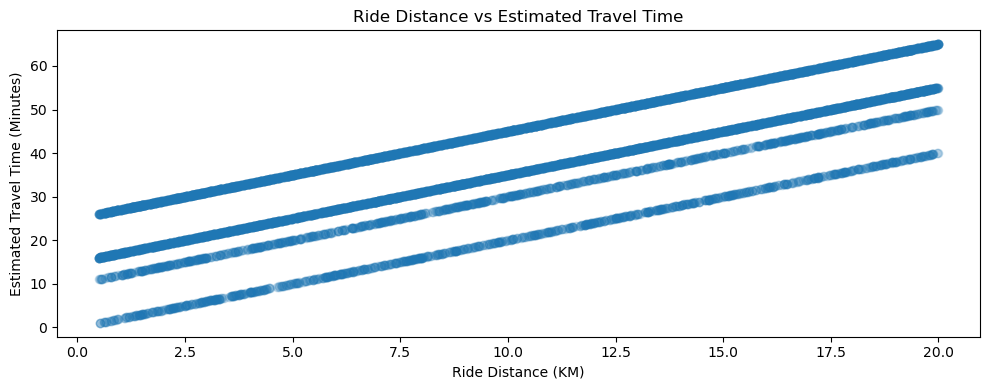

In [160]:
plt.figure(figsize=(10, 4))

plt.scatter(df_ml["Ride_Distance_KM"],df_ml["Estimated_Travel_Time"],alpha=0.2)
plt.xlabel("Ride Distance (KM)")
plt.ylabel("Estimated Travel Time (Minutes)")
plt.title("Ride Distance vs Estimated Travel Time")
plt.tight_layout()
plt.show()

# Define Fare Prediction Features

In [162]:
fare_features = [
    "Ride_Distance_KM",
    "Demand_Level",
    "Surge_Multiplier",
    "Traffic_Delay",
    "Driver_Performance_Score",
    "Driver_Trust_Score",
    "Hour_of_Day",
    "Is_Weekend"
]

fare_target = "Final_Fare"

print("Fare Features:")
print(fare_features)
print("\nFare Target:", fare_target)

Fare Features:
['Ride_Distance_KM', 'Demand_Level', 'Surge_Multiplier', 'Traffic_Delay', 'Driver_Performance_Score', 'Driver_Trust_Score', 'Hour_of_Day', 'Is_Weekend']

Fare Target: Final_Fare


# Prepare Fare Prediction Data

In [163]:
X_fare = df_ml[fare_features]
y_fare = df_ml[fare_target]

print("Fare input shape:", X_fare.shape)
print("Fare target shape:", y_fare.shape)

Fare input shape: (10000, 8)
Fare target shape: (10000,)


# Split Fare Data into Training and Testing Sets

In [164]:
X_train_fare, X_test_fare, y_train_fare, y_test_fare = train_test_split(
    X_fare, y_fare, test_size=0.20, random_state=42
)

print("Fare training records:", len(X_train_fare))
print("Fare testing records:", len(X_test_fare))

Fare training records: 8000
Fare testing records: 2000


# Train the Fare Linear Regression Model

In [165]:
fare_scaler = StandardScaler()

X_train_fare_scaled = fare_scaler.fit_transform(X_train_fare)
X_test_fare_scaled = fare_scaler.transform(X_test_fare)

fare_model = LinearRegression()
fare_model.fit(X_train_fare_scaled, y_train_fare)

print("Fare Linear Regression model trained successfully.")

Fare Linear Regression model trained successfully.


# Generate Fare Predictions

In [166]:
fare_prediction = fare_model.predict(X_test_fare_scaled)

print("First 10 predicted fares:")
print(fare_prediction[:10])

First 10 predicted fares:
[198.57978734 180.80149767 142.6704876   66.94352022  87.04867431
 244.78776601 145.62751108 273.24814946 224.9007665  246.33812632]


# Evaluate Fare Prediction

In [170]:
fare_actual = y_test_fare.to_numpy()

fare_mse = np.mean((fare_actual - fare_prediction) ** 2)
fare_rmse = np.sqrt(fare_mse)

fare_ss_res = np.sum((fare_actual - fare_prediction) ** 2)
fare_ss_tot = np.sum((fare_actual - np.mean(fare_actual)) ** 2)
fare_r2 = 1 - (fare_ss_res / fare_ss_tot)

print("===== FARE PREDICTION EVALUATION =====")
print("Mean Squared Error        :", round(fare_mse, 2))
print("Root Mean Squared Error   :", round(fare_rmse, 2))
print("R² Score                  :", round(fare_r2, 4))

===== FARE PREDICTION EVALUATION =====
Mean Squared Error        : 1032.97
Root Mean Squared Error   : 32.14
R² Score                  : 0.8881


# Visualize Actual and Predicted Fare

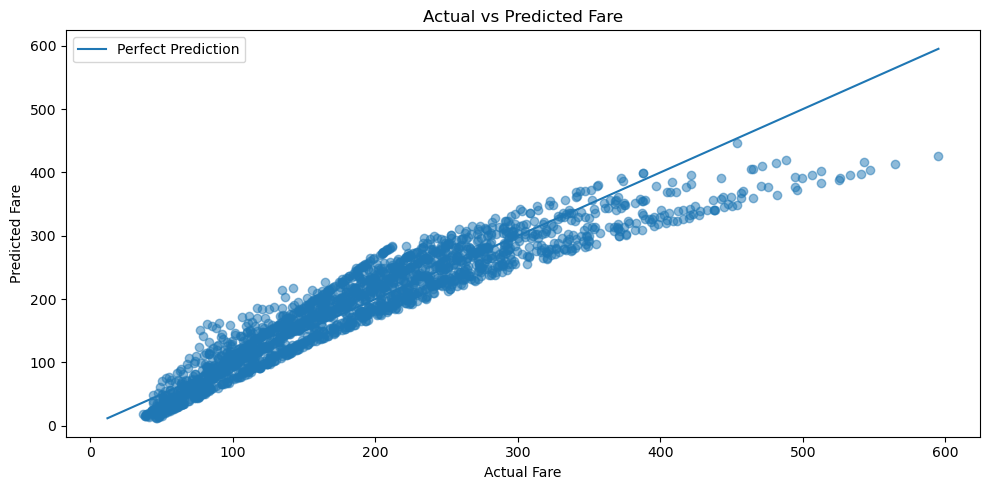

In [179]:
plt.figure(figsize=(10, 5))

plt.scatter(
    y_test_fare,
    fare_prediction,
    alpha=0.5
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")

minimum = min(y_test_fare.min(), fare_prediction.min())
maximum = max(y_test_fare.max(), fare_prediction.max())

plt.plot([minimum, maximum],[minimum, maximum],linestyle="-",label="Perfect Prediction")
plt.legend()

plt.tight_layout()
plt.show()

# Define Travel Time Prediction Features

In [181]:
time_features = [
    "Ride_Distance_KM",
    "Traffic_Delay",
    "Demand_Level",
    "Hour_of_Day",
    "Is_Weekend"
]

time_target = "Estimated_Travel_Time"

print("Travel Time Features:")
print(time_features)
print("\nTravel Time Target:", time_target)

Travel Time Features:
['Ride_Distance_KM', 'Traffic_Delay', 'Demand_Level', 'Hour_of_Day', 'Is_Weekend']

Travel Time Target: Estimated_Travel_Time


# Prepare Travel Time Prediction Data

In [182]:
X_time = df_ml[time_features]
y_time = df_ml[time_target]

print("Travel Time input shape:", X_time.shape)
print("Travel Time target shape:", y_time.shape)

Travel Time input shape: (10000, 5)
Travel Time target shape: (10000,)


# Split Travel Time Data into Training and Testing Sets

In [183]:
X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(
    X_time, y_time, test_size=0.20, random_state=42
)

print("Travel Time training records:", len(X_train_time))
print("Travel Time testing records:", len(X_test_time))

Travel Time training records: 8000
Travel Time testing records: 2000


# Train the Travel Time Linear Regression Model

In [184]:
time_scaler = StandardScaler()

X_train_time_scaled = time_scaler.fit_transform(X_train_time)
X_test_time_scaled = time_scaler.transform(X_test_time)

time_model = LinearRegression()
time_model.fit(X_train_time_scaled, y_train_time)

print("Travel Time Linear Regression model trained successfully.")

Travel Time Linear Regression model trained successfully.


# Generate Travel Time Predictions

In [189]:
time_prediction = time_model.predict(X_test_time_scaled)

print("First 10 predicted travel times:")
print(time_prediction[:10])

First 10 predicted travel times:
[52.98 28.3  23.96 18.66 36.72 59.52 35.2  44.54 39.62 49.66]


# Evaluate Travel Time Prediction

In [190]:
time_actual = y_test_time.to_numpy()

time_mse = np.mean((time_actual - time_prediction) ** 2)
time_rmse = np.sqrt(time_mse)

time_ss_res = np.sum((time_actual - time_prediction) ** 2)
time_ss_tot = np.sum((time_actual - np.mean(time_actual)) ** 2)
time_r2 = 1 - (time_ss_res / time_ss_tot)

print("===== TRAVEL TIME EVALUATION =====")
print("Mean Squared Error        :", round(time_mse, 2))
print("Root Mean Squared Error   :", round(time_rmse, 2))
print("R² Score                  :", round(time_r2, 4))

===== TRAVEL TIME EVALUATION =====
Mean Squared Error        : 0.0
Root Mean Squared Error   : 0.0
R² Score                  : 1.0


# Visualize Actual and Predicted Travel Time

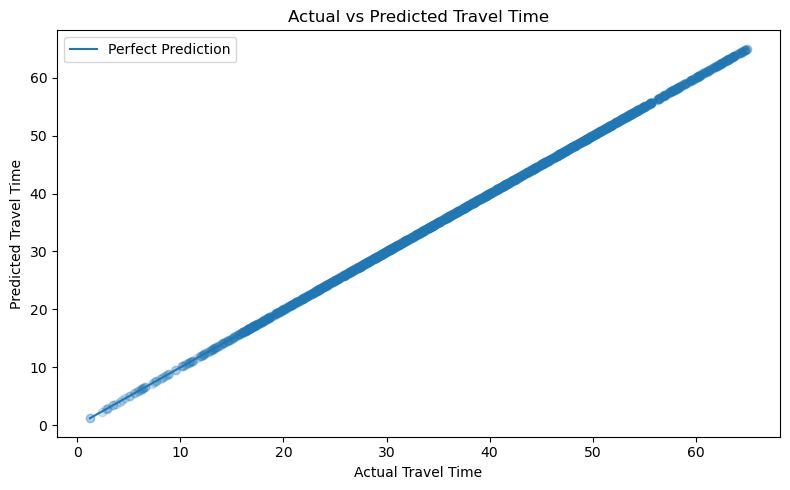

In [195]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test_time,time_prediction,alpha=0.2)
plt.xlabel("Actual Travel Time")
plt.ylabel("Predicted Travel Time")
plt.title("Actual vs Predicted Travel Time")

minimum = min(y_test_time.min(),time_prediction.min())

maximum = max(y_test_time.max(),time_prediction.max())

plt.plot([minimum, maximum],[minimum, maximum],linestyle="-",label="Perfect Prediction")
plt.legend()

plt.tight_layout()
plt.show()

### Define the Delay Risk Target

In [197]:
delay_threshold = df_ml["Traffic_Delay"].median()

print("Traffic Delay Threshold:",delay_threshold)
df_ml["Delay_Risk"] = np.where(df_ml["Traffic_Delay"] > delay_threshold,1,0)

print("\nDelay Risk Encoding:")
print("0 = Low Delay Risk")
print("1 = High Delay Risk")

Traffic Delay Threshold: 15.0

Delay Risk Encoding:
0 = Low Delay Risk
1 = High Delay Risk


# Analyze Delay Risk Distribution

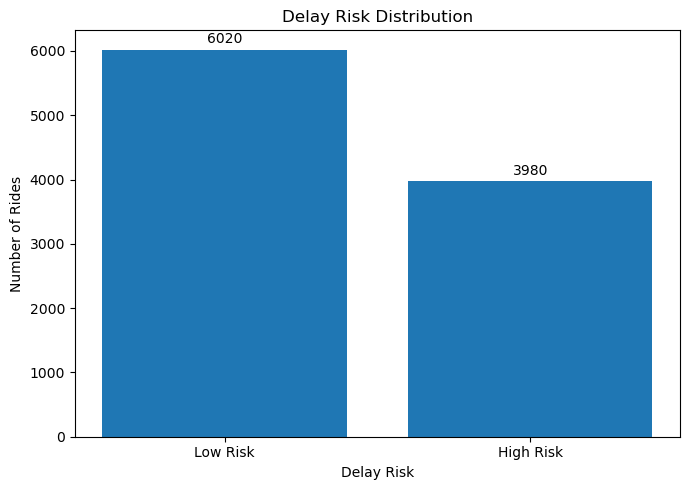

In [199]:
risk_labels = ["Low Risk", "High Risk"]
risk_values = [risk_counts.get(0, 0),risk_counts.get(1, 0)]

plt.figure(figsize=(7, 5))

bars = plt.bar(risk_labels,risk_values)

plt.xlabel("Delay Risk")
plt.ylabel("Number of Rides")
plt.title("Delay Risk Distribution")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Define Delay Risk Features

In [212]:
delay_features = [
    "Ride_Distance_KM",
    "Available_Drivers",
    "Demand_Level",
    "Demand_Score",
    "Driver_Availability",
    "Surge_Multiplier",
    "Hour_of_Day",
    "Is_Weekend",
    "Driver_Performance_Score",
    "Driver_Trust_Score"
]

delay_target = "Delay_Risk"

print("Delay Features:")
print(delay_features)
print("\nDelay Target:", delay_target)

Delay Features:
['Ride_Distance_KM', 'Available_Drivers', 'Demand_Level', 'Demand_Score', 'Driver_Availability', 'Surge_Multiplier', 'Hour_of_Day', 'Is_Weekend', 'Driver_Performance_Score', 'Driver_Trust_Score']

Delay Target: Delay_Risk


# Prepare Delay Risk Prediction Data

In [213]:
X_delay = df_ml[delay_features]
y_delay = df_ml[delay_target]

print("Delay input shape:", X_delay.shape)
print("Delay target shape:", y_delay.shape)

Delay input shape: (10000, 10)
Delay target shape: (10000,)


# Split Delay Risk Data into Training and Testing Sets

In [214]:
X_train_delay, X_test_delay, y_train_delay, y_test_delay = train_test_split(
    X_delay, y_delay, test_size=0.20, random_state=42, stratify=y_delay
)

print("Delay training records:", len(X_train_delay))
print("Delay testing records:", len(X_test_delay))

Delay training records: 8000
Delay testing records: 2000


# Train the Delay Risk Logistic Regression Model

In [223]:
delay_scaler = StandardScaler()

X_train_delay_scaled = delay_scaler.fit_transform(X_train_delay)
X_test_delay_scaled = delay_scaler.transform(X_test_delay)

delay_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

delay_model.fit(X_train_delay_scaled,y_train_delay)

print("Delay Risk Logistic Regression model trained successfully.")

Delay Risk Logistic Regression model trained successfully.


# Generate Delay Risk Predictions

In [224]:
delay_prediction = delay_model.predict(X_test_delay_scaled)

print("First 20 predicted delay-risk classes:")
print(delay_prediction[:20])

First 20 predicted delay-risk classes:
[1 0 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0]


# Evaluate Delay Risk Prediction

In [225]:
delay_accuracy = accuracy_score(y_test_delay,delay_prediction)
delay_precision = precision_score(y_test_delay,delay_prediction)
delay_recall = recall_score(y_test_delay,delay_prediction)
delay_f1 = f1_score(y_test_delay,delay_prediction)

print("===== DELAY RISK EVALUATION =====")
print("Accuracy  :", round(delay_accuracy, 4))
print("Precision :", round(delay_precision, 4))
print("Recall    :", round(delay_recall, 4))
print("F1 Score  :", round(delay_f1, 4))

===== DELAY RISK EVALUATION =====
Accuracy  : 0.7855
Precision : 0.6498
Recall    : 1.0
F1 Score  : 0.7877


In [226]:
print("Actual classes:")
print(pd.Series(y_test_delay).value_counts())

print("\nPredicted classes:")
print(pd.Series(delay_prediction).value_counts())

Actual classes:
Delay_Risk
0    1204
1     796
Name: count, dtype: int64

Predicted classes:
1    1225
0     775
Name: count, dtype: int64


# Evaluate Delay Risk Confusion Matrix

In [228]:
delay_cm = confusion_matrix(
    y_test_delay,
    delay_prediction
)

print("Confusion Matrix:")
print(delay_cm)

Confusion Matrix:
[[775 429]
 [  0 796]]


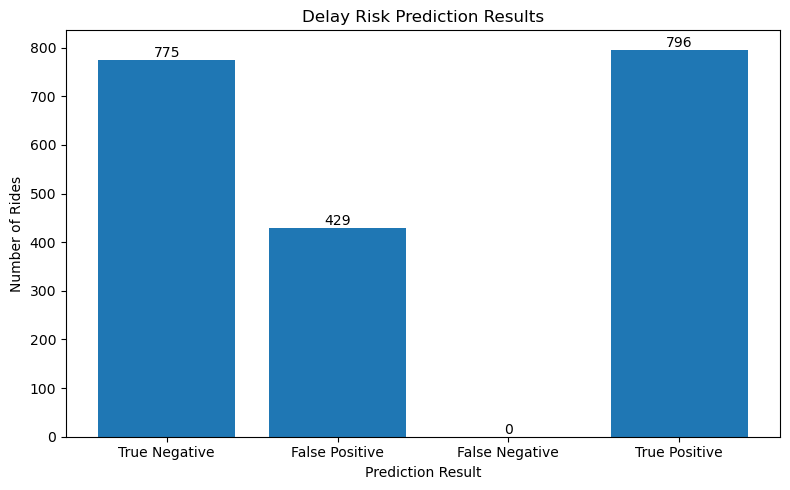

In [243]:
delay_cm = confusion_matrix(y_test_delay,delay_prediction)

tn = delay_cm[0, 0]
fp = delay_cm[0, 1]
fn = delay_cm[1, 0]
tp = delay_cm[1, 1]

labels = ["True Negative","False Positive","False Negative","True Positive"]
values = [tn,fp,fn,tp]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels,values)

plt.xlabel("Prediction Result")
plt.ylabel("Number of Rides")
plt.title("Delay Risk Prediction Results")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() ,
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Summarize Classification Result

In [244]:
classification_results = pd.DataFrame({
    "Task": ["Delay Risk Prediction"],
    "Model": ["Logistic Regression"],
    "Accuracy Score (in %)": [delay_accuracy * 100],
    "Precision Score (in %)": [delay_precision * 100],
    "Recall Score (in %)": [delay_recall * 100],
    "F1 Score (in %)": [delay_f1 * 100]
})

classification_results

,Task,Model,Accuracy Score (in %),Precision Score (in %),Recall Score (in %),F1 Score (in %)
0,Delay Risk Prediction,Logistic Regression,78.55,64.979592,100.0,78.772885
